## Setup
Install dependencies, set the working directory, and import all libraries.

In [1]:
%pip install xgboost imbalanced-learn joblib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
from pathlib import Path

# Set working directory to the notebook folder (VS Code local execution)
try:
    notebook_dir = Path(__vsc_ipynb_file__).parent
    os.chdir(notebook_dir)
except NameError:
    pass

print("Working directory:", os.getcwd())

for folder in ["outputs/graphs", "models", "dashboard"]:
    os.makedirs(folder, exist_ok=True)

print("Folders ready.")

Working directory: c:\Users\User\Desktop\New June Assignment\Asg 1\Coding
Folders ready.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

print("All imports OK.")

All imports OK.


## Load Dataset

In [ ]:
# Memory-optimised loading - default float64 + string ID columns use ~1.5 GB and crash the kernel.
# Using float32 + skipping nameOrig/nameDest reduces RAM to ~200 MB.
dtypes = {
    "step":           "int32",
    "type":           "category",
    "amount":         "float32",
    "oldbalanceOrg":  "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud":        "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv("paysim.csv", dtype=dtypes, usecols=list(dtypes.keys()))

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Memory usage:", round(df.memory_usage(deep=True).sum() / 1e6, 1), "MB")
df.head()

Dataset loaded successfully
Shape: (6362620, 9)
Memory usage: 171.8 MB


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,170136.0,160296.359375,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,21249.0,19384.720703,0.0,0.0,0,0
2,1,TRANSFER,181.000000,181.0,0.000000,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,181.0,0.000000,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,41554.0,29885.859375,0.0,0.0,0,0


## Exploratory Data Analysis

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nTransaction types:")
print(df["type"].value_counts())

print("\nFraud distribution:")
print(df["isFraud"].value_counts())

print("\nFraud %:")
print(df["isFraud"].value_counts(normalize=True).mul(100).round(2))

Missing values:
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud %:
isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64


In [24]:

# Descriptive statistics for numeric columns
df[[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
amount,6362620.0,1.798619e+05,603858.25,0.0,13389.570312,74871.937500,2.087215e+05,92445520.0
oldbalanceOrg,6362620.0,8.338831e+05,2888242.75,0.0,0.000000,14208.000000,1.073152e+05,59585040.0
newbalanceOrig,6362620.0,8.551136e+05,2924048.50,0.0,0.000000,0.000000,1.442584e+05,49585040.0
oldbalanceDest,6362620.0,1.100702e+06,3399180.25,0.0,0.000000,132705.664062,9.430367e+05,356015904.0
newbalanceDest,6362620.0,1.224996e+06,3674129.00,0.0,0.000000,214661.445312,1.111909e+06,356179264.0


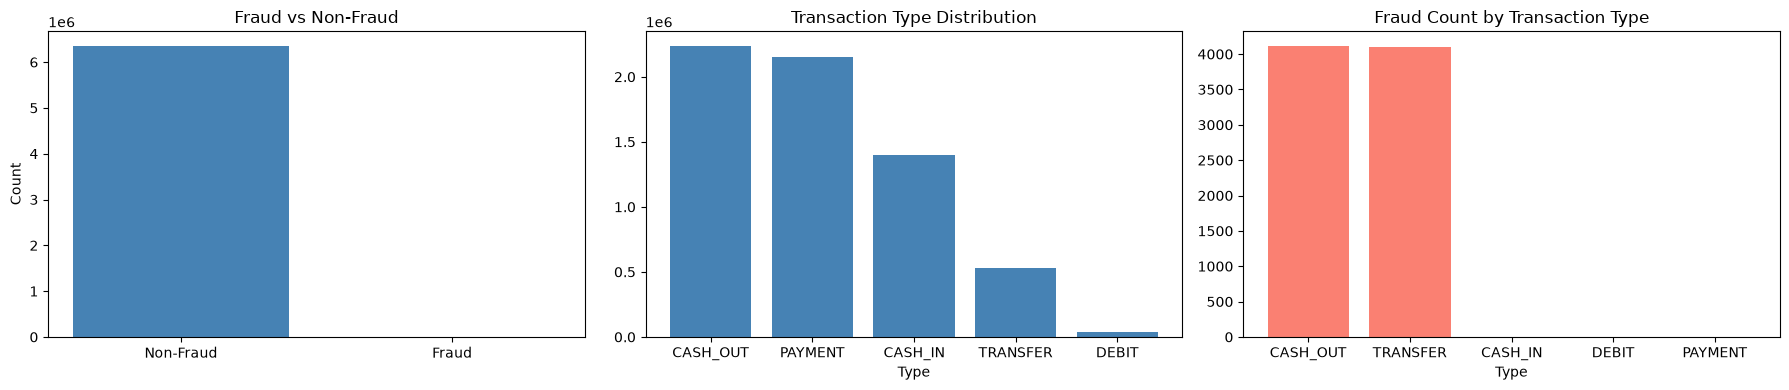

EDA graphs saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Fraud vs Non-Fraud
counts = df["isFraud"].value_counts().sort_index()
axes[0].bar(["Non-Fraud", "Fraud"], counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Fraud vs Non-Fraud")
axes[0].set_ylabel("Count")

# Transaction type distribution
type_counts = df["type"].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color="steelblue")
axes[1].set_title("Transaction Type Distribution")
axes[1].set_xlabel("Type")

# Fraud count by transaction type
fraud_by_type = df.groupby("type")["isFraud"].sum().sort_values(ascending=False)
axes[2].bar(fraud_by_type.index, fraud_by_type.values, color="salmon")
axes[2].set_title("Fraud Count by Transaction Type")
axes[2].set_xlabel("Type")

plt.tight_layout()
plt.savefig("outputs/graphs/eda_overview.png", dpi=150)
plt.show()
print("EDA graphs saved.")

## Feature Engineering & Modelling Dataset

In [7]:
# Use all fraud records + 300,000 random non-fraud records
fraud_df     = df[df["isFraud"] == 1]
non_fraud_df = df[df["isFraud"] == 0].sample(n=300000, random_state=42)

df_model = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Model dataset shape:", df_model.shape)
print(df_model["isFraud"].value_counts())

Model dataset shape: (308213, 9)
isFraud
0    300000
1      8213
Name: count, dtype: int64


In [ ]:
# Engineered features
df_model["balanceDiffOrig"]         = df_model["oldbalanceOrg"]  - df_model["newbalanceOrig"]
df_model["balanceDiffDest"]         = df_model["newbalanceDest"] - df_model["oldbalanceDest"]
df_model["amountToOldBalanceRatio"] = df_model["amount"] / (df_model["oldbalanceOrg"] + 1)

# Drop isFlaggedFraud (nameOrig/nameDest were not loaded - already excluded)
model_df = df_model.drop(columns=["isFlaggedFraud"])

# One-hot encode transaction type
model_df = pd.get_dummies(model_df, columns=["type"], drop_first=True)

X = model_df.drop(columns=["isFraud"])
y = model_df["isFraud"]

print("Feature matrix shape:", X.shape)
print("Columns:", X.columns.tolist())

Feature matrix shape: (308213, 13)
Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'amountToOldBalanceRatio', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("\nFraud in train:", y_train.sum(), " / Non-fraud:", (y_train == 0).sum())

Train: (246570, 13)
Test:  (61643, 13)

Fraud in train: 6570  / Non-fraud: 240000


## Scale Features (for Logistic Regression)

In [10]:
numeric_cols = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "balanceDiffOrig", "balanceDiffDest", "amountToOldBalanceRatio"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test_scaled[numeric_cols])

print("Scaling done.")

Scaling done.


## Model Training

### Logistic Regression

In [11]:
# --- Logistic Regression ---
print("Training Logistic Regression...")

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)

print("Done.")
print(classification_report(y_test, log_pred))

Training Logistic Regression...
Done.
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     60000
           1       0.34      0.95      0.50      1643

    accuracy                           0.95     61643
   macro avg       0.67      0.95      0.74     61643
weighted avg       0.98      0.95      0.96     61643



### Random Forest

In [12]:
# --- Random Forest ---
print(f"Training Random Forest on {X_train.shape[0]:,} rows using {os.cpu_count()} CPU cores...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Done.")
print(classification_report(y_test, rf_pred))

Training Random Forest on 246,570 rows using 16 CPU cores...
Done.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     60000
           1       1.00      1.00      1.00      1643

    accuracy                           1.00     61643
   macro avg       1.00      1.00      1.00     61643
weighted avg       1.00      1.00      1.00     61643



### XGBoost

In [13]:
# --- XGBoost ---
print(f"Training XGBoost on {X_train.shape[0]:,} rows...")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    nthread=-1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("Done.")
print(classification_report(y_test, xgb_pred))

Training XGBoost on 246,570 rows...
Done.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     60000
           1       1.00      1.00      1.00      1643

    accuracy                           1.00     61643
   macro avg       1.00      1.00      1.00     61643
weighted avg       1.00      1.00      1.00     61643



## Model Comparison

In [14]:
def evaluate(name, y_true, y_pred):
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-score":  round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

results_df = pd.DataFrame([
    evaluate("Logistic Regression", y_test, log_pred),
    evaluate("Random Forest",       y_test, rf_pred),
    evaluate("XGBoost",             y_test, xgb_pred),
])

results_df.to_csv("outputs/model_results.csv", index=False)
print("Saved outputs/model_results.csv")
results_df

Saved outputs/model_results.csv


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9491,0.3380,0.9483,0.4983
1,Random Forest,0.9999,0.9958,0.9988,0.9973
2,XGBoost,0.9999,0.9964,0.9988,0.9976


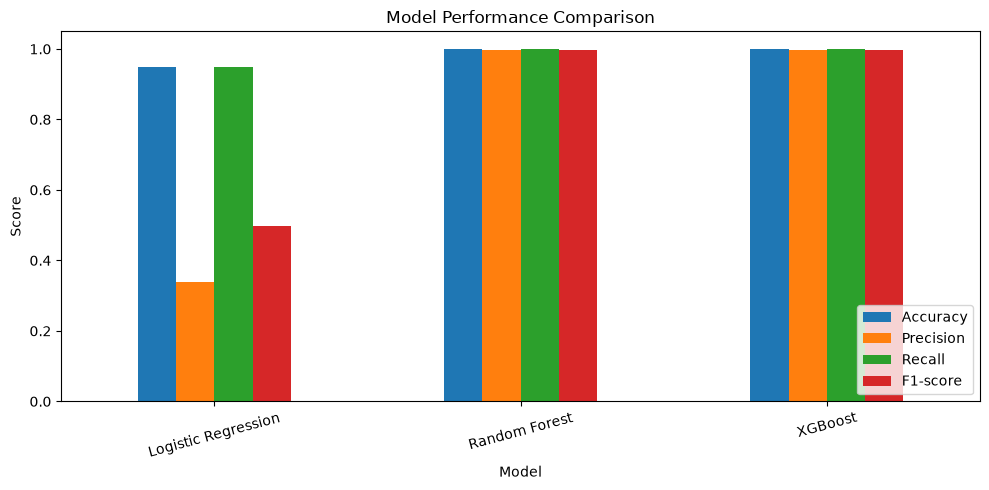

In [15]:
ax = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/graphs/model_comparison.png", dpi=150)
plt.show()

## Confusion Matrix (Random Forest)

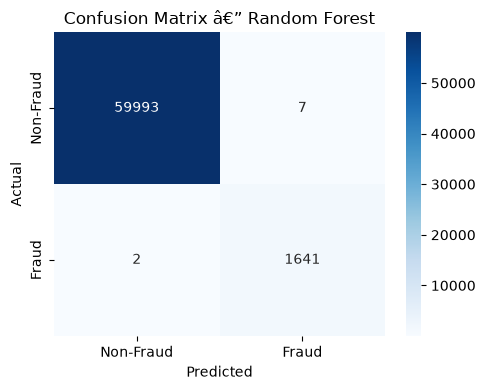

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/graphs/confusion_matrix.png", dpi=150)
plt.show()

## Feature Importance (Random Forest)

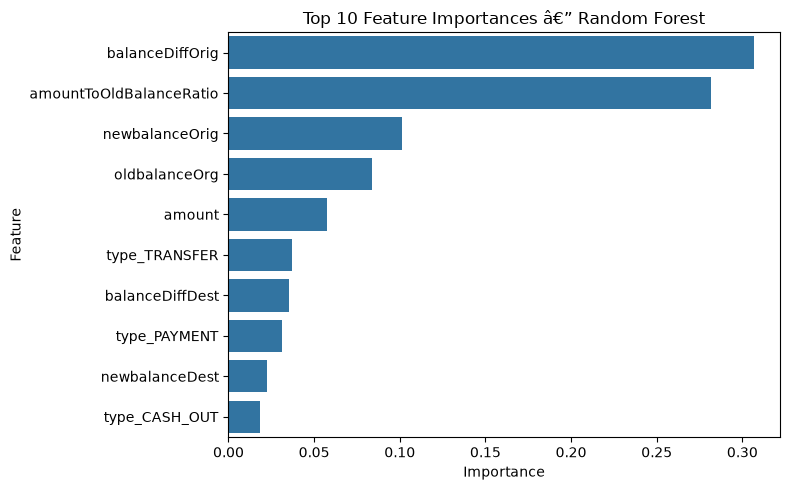

,Feature,Importance
6,balanceDiffOrig,0.306637
8,amountToOldBalanceRatio,0.281951
3,newbalanceOrig,0.101165
2,oldbalanceOrg,0.083920
1,amount,0.057490
12,type_TRANSFER,0.037243
7,balanceDiffDest,0.035171
11,type_PAYMENT,0.031506
5,newbalanceDest,0.022418
9,type_CASH_OUT,0.018402


In [ ]:
feature_importance = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.savefig("outputs/graphs/feature_importance.png", dpi=150)
plt.show()

feature_importance.to_csv("outputs/feature_importance.csv", index=False)
feature_importance.head(10)

## Save Models

In [21]:
joblib.dump(rf_model,            "models/random_forest_model.pkl")
joblib.dump(scaler,              "models/scaler.pkl")
joblib.dump(X.columns.tolist(),  "models/feature_columns.pkl")

print("Saved:")
print("  models/random_forest_model.pkl")
print("  models/scaler.pkl")
print("  models/feature_columns.pkl")

Saved:
  models/random_forest_model.pkl
  models/scaler.pkl
  models/feature_columns.pkl


## Streamlit Dashboard

In [ ]:
%%writefile dashboard/app.py
import streamlit as st
import pandas as pd
import joblib
import os

st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")
st.title("Mobile Money Fraud Detection Dashboard")

MODEL_PATH   = "models/random_forest_model.pkl"
FEATURE_PATH = "models/feature_columns.pkl"
RESULTS_PATH = "outputs/model_results.csv"
GRAPH_PATH   = "outputs/graphs"

model           = joblib.load(MODEL_PATH)
feature_columns = joblib.load(FEATURE_PATH)

st.header("1. Model Performance")
if os.path.exists(RESULTS_PATH):
    st.dataframe(pd.read_csv(RESULTS_PATH))
else:
    st.warning("Run the notebook first to generate model_results.csv")

st.header("2. EDA & Results Graphs")
for graph in ["eda_overview.png", "model_comparison.png",
              "confusion_matrix.png", "feature_importance.png"]:
    path = os.path.join(GRAPH_PATH, graph)
    if os.path.exists(path):
        st.image(path, caption=graph.replace("_", " ").replace(".png", "").title())

st.header("3. Predict a Transaction")
col1, col2 = st.columns(2)
with col1:
    step             = st.number_input("Step",                    min_value=1,   value=1)
    transaction_type = st.selectbox("Transaction Type",
                                    ["CASH_IN","CASH_OUT","DEBIT","PAYMENT","TRANSFER"])
    amount           = st.number_input("Amount",                  min_value=0.0, value=1000.0)
    oldbalanceOrg    = st.number_input("Sender Old Balance",      min_value=0.0, value=5000.0)
    newbalanceOrig   = st.number_input("Sender New Balance",      min_value=0.0, value=4000.0)
with col2:
    oldbalanceDest   = st.number_input("Receiver Old Balance",    min_value=0.0, value=1000.0)
    newbalanceDest   = st.number_input("Receiver New Balance",    min_value=0.0, value=2000.0)

input_data = pd.DataFrame([{
    "step": step, "amount": amount,
    "oldbalanceOrg": oldbalanceOrg, "newbalanceOrig": newbalanceOrig,
    "oldbalanceDest": oldbalanceDest, "newbalanceDest": newbalanceDest,
    "balanceDiffOrig":         oldbalanceOrg - newbalanceOrig,
    "balanceDiffDest":         newbalanceDest - oldbalanceDest,
    "amountToOldBalanceRatio": amount / (oldbalanceOrg + 1),
    "type_CASH_OUT": int(transaction_type == "CASH_OUT"),
    "type_DEBIT":    int(transaction_type == "DEBIT"),
    "type_PAYMENT":  int(transaction_type == "PAYMENT"),
    "type_TRANSFER": int(transaction_type == "TRANSFER"),
}])
for col in feature_columns:
    if col not in input_data.columns:
        input_data[col] = 0
input_data = input_data[feature_columns]

if st.button("Predict"):
    pred = model.predict(input_data)[0]
    if pred == 1:
        st.error("Prediction: FRAUDULENT Transaction")
    else:
        st.success("Prediction: Legitimate Transaction")

st.caption("Academic prototype - not connected to a real banking system.")

Overwriting dashboard/app.py


### Launch the Dashboard

In [20]:
print("Dashboard written to dashboard/app.py")
print()
print("To launch, open a terminal in this folder and run:")
print("  streamlit run dashboard/app.py")

Dashboard written to dashboard/app.py

To launch, open a terminal in this folder and run:
  streamlit run dashboard/app.py
